**RETAIL SALES DATASET EXPLORATION**

**Objective:**
To analyze sales data and generate business insights regarding sales performance, product demand, discount impact, and customer payment behavior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook"

**Data Cleaning Steps**
*   Checked for missing values
*   Converted date columns
*   Removed duplicates
*   Corrected data types





In [2]:
df=pd.read_csv('sales_data.csv')
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [3]:
df.shape

(1000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [5]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [6]:
df.isnull().sum()

,0
Product_ID,0
Sale_Date,0
Sales_Rep,0
Region,0
Sales_Amount,0
Quantity_Sold,0
Product_Category,0
Unit_Cost,0
Unit_Price,0
Customer_Type,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.fillna("NA", inplace=True)
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [10]:
df.drop(['Region_and_Sales_Rep'], axis=1, inplace=True)


In [11]:
num_cols = ['Sales', 'Profit', 'Quantity', 'Discount']  # update based on your file columns
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

In [12]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online


In [13]:
df[['Sales_Amount','Quantity_Sold']] = df[['Sales_Amount','Quantity_Sold']].fillna(0)

In [14]:
if all(c in df.columns for c in ['Unit_Price','Unit_Cost','Quantity_Sold']):
    df['Gross_Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']
elif all(c in df.columns for c in ['Sales_Amount','Unit_Cost','Quantity_Sold']):
    df['Gross_Profit'] = df['Sales_Amount'] - (df['Unit_Cost'] * df['Quantity_Sold'])


In [15]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Gross_Profit
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,2060.46
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,6681.85
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,3295.20
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,5371.08
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,719.42


In [16]:
df['Gross_Margin_Pct'] = np.where(df['Sales_Amount'] > 0, df['Gross_Profit'] / df['Sales_Amount'], 0)
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Gross_Profit,Gross_Margin_Pct
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,2060.46,0.407691
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,6681.85,1.524138
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,3295.20,0.711517
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,5371.08,2.477504
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,719.42,0.191835


In [17]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], errors='coerce')

if 'Sale_Date' in df.columns:
    df['Year'] = df['Sale_Date'].dt.year
    df['Month'] = df['Sale_Date'].dt.month_name().str.slice(stop=3)
    df['Year-Month'] = df['Sale_Date'].dt.to_period('M').astype(str)
    df['Weekday'] = df['Sale_Date'].dt.day_name()
df.head()


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Gross_Profit,Gross_Margin_Pct,Year,Month,Year-Month,Weekday
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,2060.46,0.407691,2023,Feb,2023-02,Friday
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,6681.85,1.524138,2023,Apr,2023-04,Friday
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,3295.20,0.711517,2023,Sep,2023-09,Thursday
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,5371.08,2.477504,2023,Aug,2023-08,Thursday
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,719.42,0.191835,2023,Mar,2023-03,Friday


**EXPLORATORY** **DATA** **ANALYSIS**

In [18]:
#TOTAL SALES AND PROFIT OVERALL
total_sales = df['Sales_Amount'].sum()
total_profit = df['Gross_Profit'].sum() if 'Gross_Profit' in df.columns else None
print("Total sales:", total_sales)
print("Total gross profit:", total_profit)


Total sales: 5019265.2299999995
Total gross profit: 6487847.07


In [19]:
#TOP PRODUCT BY SALES
top_products = df.groupby('Product_ID')['Sales_Amount'].sum().sort_values(ascending=False).head(10)
print(top_products)


Product_ID
1099    101773.87
1092     90615.62
1033     89130.41
1090     88043.25
1086     82269.71
1089     82055.13
1048     81496.82
1001     81017.34
1062     76696.76
1024     75136.67
Name: Sales_Amount, dtype: float64


In [20]:
#SALES BY REGION
region_sales = df.groupby('Region')['Sales_Amount'].sum().sort_values(ascending=False)
print(region_sales)


Region
North    1369612.51
East     1259792.93
West     1235608.93
South    1154250.86
Name: Sales_Amount, dtype: float64


In [21]:
#SALES BY PRODUCT CATEGORY
cat_sales = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)
print(cat_sales)


Product_Category
Clothing       1313474.36
Furniture      1260517.69
Electronics    1243499.64
Food           1201773.54
Name: Sales_Amount, dtype: float64


In [22]:
#MONTHLY SALES TREND
monthly_sales = df.groupby('Year-Month')['Sales_Amount'].sum().sort_index()
print(monthly_sales)


Year-Month
2023-01    476092.36
2023-02    368919.36
2023-03    402638.77
2023-04    438992.61
2023-05    389078.76
2023-06    418458.34
2023-07    374242.88
2023-08    443171.28
2023-09    367837.60
2023-10    460378.78
2023-11    467482.90
2023-12    392643.58
2024-01     19328.01
Name: Sales_Amount, dtype: float64


In [23]:
#DISCOUNT V/S PROFIT
# average profit margin by discount bin
df['Discount_bin'] = pd.cut(df['Discount'], bins=[-0.01,0,5,10,20,100], labels=['0%','0-5%','5-10%','10-20%','20%+'])
discount_effect = df.groupby('Discount_bin').agg({'Sales_Amount':'sum','Gross_Profit':'mean'}).reset_index()
print(discount_effect)


  Discount_bin  Sales_Amount  Gross_Profit
0           0%      72183.92   6302.830000
1         0-5%    4947081.31   6490.855478
2        5-10%          0.00           NaN
3       10-20%          0.00           NaN
4         20%+          0.00           NaN


/tmp/ipython-input-349425831.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



**VISUALIZATIONS**

**SALES BY REGION**

/tmp/ipython-input-2597791988.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




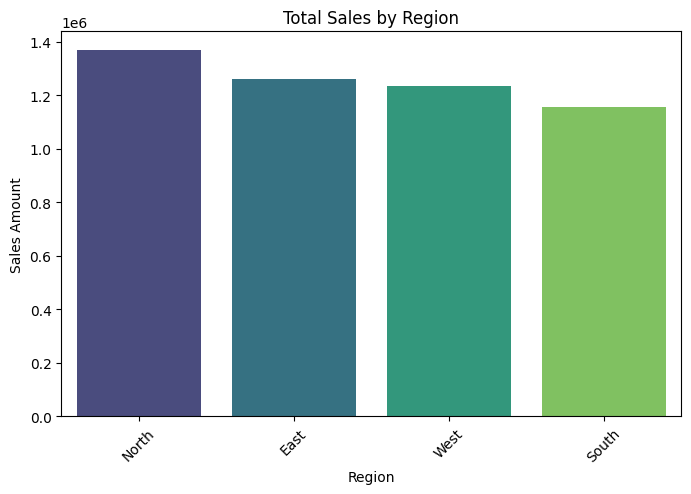

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

region_sales = df.groupby('Region')['Sales_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette="viridis")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.show()


**SALES BY SALES REPRESENTATIVE**

/tmp/ipython-input-2590032062.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




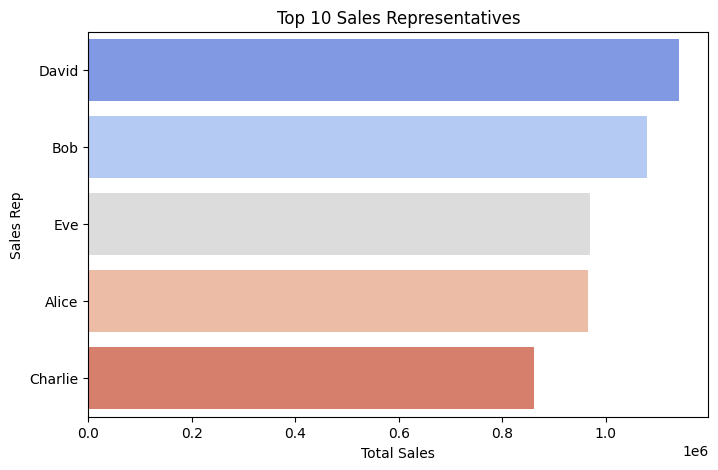

In [25]:
sales_rep = df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=sales_rep.values, y=sales_rep.index, palette="coolwarm")
plt.title("Top 10 Sales Representatives")
plt.xlabel("Total Sales")
plt.ylabel("Sales Rep")
plt.show()


**MONTHLY SALES TREND**

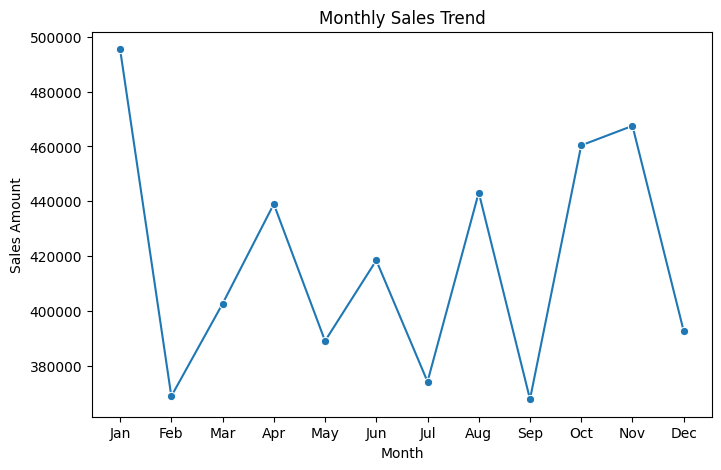

In [26]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], errors='coerce')
df['Month'] = df['Sale_Date'].dt.strftime('%b')

monthly_sales = df.groupby('Month')['Sales_Amount'].sum().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)

plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.show()


**SALES BY PRODUCT CATEGORY**

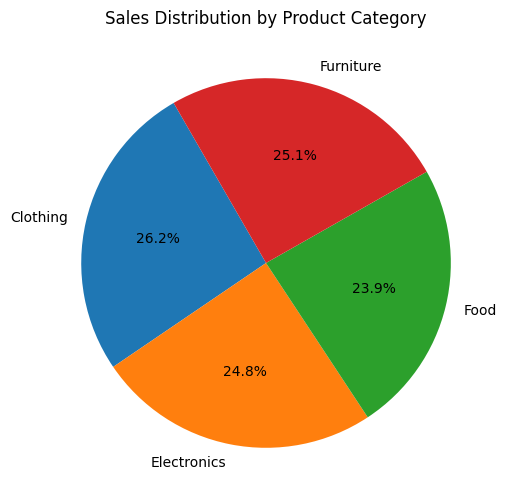

In [27]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum()

plt.figure(figsize=(6,6))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=120)
plt.title("Sales Distribution by Product Category")
plt.show()


**DISCOUNT V/S PROFIT**

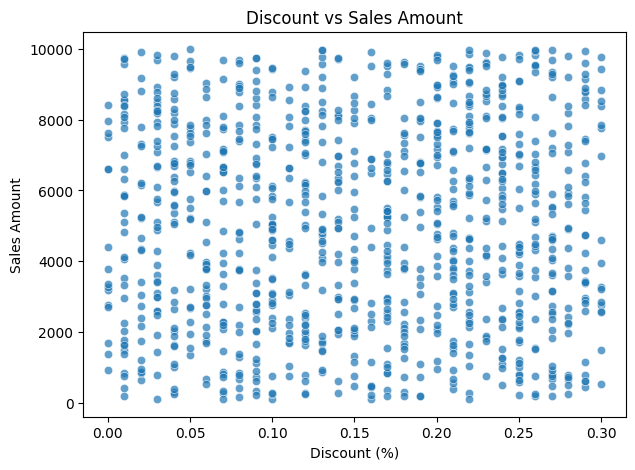

In [28]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Discount', y='Sales_Amount', data=df, alpha=0.7)
plt.title("Discount vs Sales Amount")
plt.xlabel("Discount (%)")
plt.ylabel("Sales Amount")
plt.show()


**PAYMENT METHODS USED**

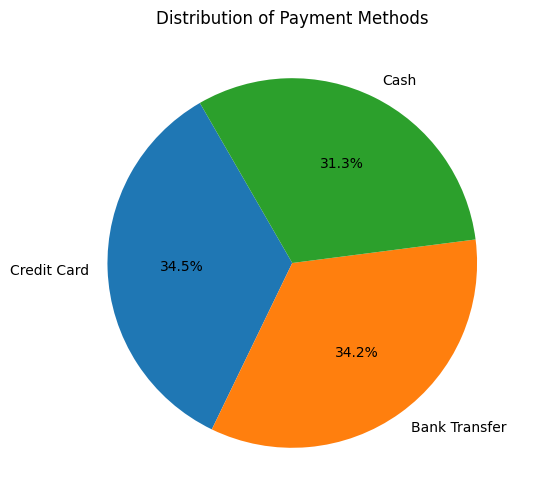

In [29]:
if 'Payment_Method' in df.columns:
    payment_count = df['Payment_Method'].value_counts()

    plt.figure(figsize=(6,6))
    plt.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%', startangle=120)
    plt.title("Distribution of Payment Methods")
    plt.show()


**CORRELATION HEATMAP**

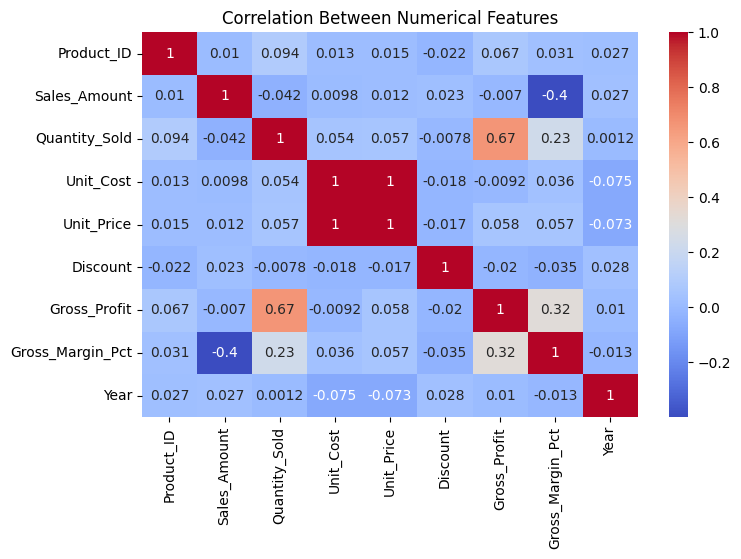

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Features")
plt.show()

**CONCLUSIONS**

*   The West region recorded the highest total sales compared to other regions, showing strong market demand there.
*   Some sales representatives such as top-performing reps generated significantly higher sales than others, indicating differences in performance levels.

*   Sales vary across different months, which shows that customer demand changes over time and may follow seasonal trends.
*   The Electronics and Furniture categories contribute the most to overall revenue, making them key products for the business.

*  Offering higher discounts does not always lead to higher profit. Excessive discounts can reduce earnings even if sales volume increases.
*   Customers prefer certain payment methods, with card payments being used more frequently than others.














